   Index         X         Y
0      1  5.000000  0.000000
1      2  5.462094  0.704259
2      3  5.785811  1.517218
3      4  5.924263  2.398468
4      5  5.846797  3.292855


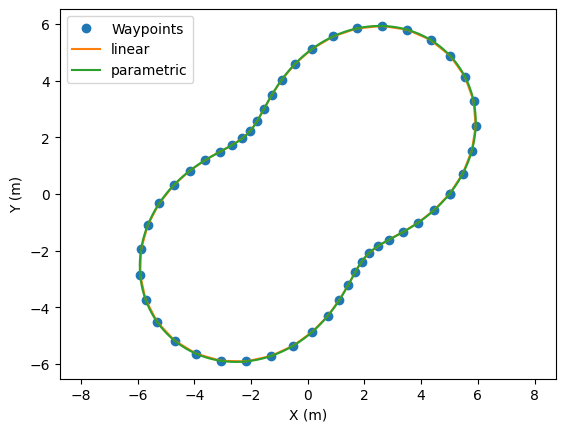

In [14]:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.interpolate import splev,splprep,interp1d

  df = pd.read_csv('loop_track_waypoints.csv')
  print(df.head())
  x = df['X'].to_numpy()
  y = df['Y'].to_numpy()

  n = len(x)
  t = np.linspace(0,n-1,n)
  t_smooth = np.linspace(0,n-1,1000)
  tx = interp1d(t,x,kind = 'linear')
  ty = interp1d(t,y,kind = 'linear')
  x_smooth = tx(t_smooth)
  y_smooth = ty(t_smooth)
  tck,u = splprep([x,y],s = 0,per = True)
  splev(x_smooth,tck)

  #plt.plot(x_smooth,y_smooth,'bo')
  x_smoooth,y_smoooth = splev(np.linspace(0,1,1000),tck)
  plt.plot(x, y, 'o', label='Waypoints')           # original waypoints
  plt.plot(x_smooth, y_smooth, label='linear')  # cubic interp1d
  plt.plot(x_smoooth, y_smoooth, label='parametric') # parametric spline
  plt.xlabel('X (m)')
  plt.ylabel('Y (m)')
  plt.legend()
  plt.axis('equal')
  plt.show()

